In [1]:
import samna
import samna.dynapse1 as dyn1
import time
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../.')

import dynapse1utils as ut
from netgen import NetworkGenerator, Neuron

import pynwb
import h5py
from pynwb import NWBHDF5IO
import os


In [ ]:
model,_ = ut.open_dynapse1(gui=False, select_device= True)

[0]:  Bus 1 Device 15 Dynapse1DevKit serial_number 00000007
[1]:  Bus 1 Device 13 Dynapse1DevKit serial_number 00000000
[2]:  Bus 1 Device 12 Dynapse1DevKit serial_number 00000001


Select the device you want to open by index:  0


In [3]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()
chip_id = 0
neuron_id = 10
api.monitor_neuron(chip_id, neuron_id)

In [7]:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

neurons_E= []
NE = 16
E_ids = [(0,0,i) for i in range(1,NE+1)]
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))
print(neurons_E)

NI= 8
I_ids = [(0,0,i) for i in range(NE+1, (NE+1)+NI+1)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))
print(neurons_I)

[C0c0n1, C0c0n2, C0c0n3, C0c0n4, C0c0n5, C0c0n6, C0c0n7, C0c0n8, C0c0n9, C0c0n10, C0c0n11, C0c0n12, C0c0n13, C0c0n14, C0c0n15, C0c0n16]
[C0c0n17, C0c0n18, C0c0n19, C0c0n20, C0c0n21, C0c0n22, C0c0n23, C0c0n24, C0c0n25]


In [12]:
D_stim = 3 # stimulus duration (s)
D_post_stim = 3 # post stimulus duration (s)
D = D_stim + D_post_stim

In [14]:
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# clear the buffer
sink_node.get_events()

api.reset_timestamp()
time.sleep(D_stim)

time.sleep(D_post_stim)
graph.stop()
events = sink_node.get_events()

# process the events
print(len(events),"events.")

4490 events.


In [19]:
NN = 256 # neurons in 1 core
spike_id = []
spike_t  = []
for evt in events:
    spike_id.append(evt.core_id*NN + evt.neuron_id)
    spike_t.append(evt.timestamp*1e-6)
spike_id = np.array(spike_id)
spike_t  = np.array(spike_t) 

In [ ]:
with NWBHDF5IO("sub-489_ses-20220708.nwb", "r") as io: #the left whisker
    nwb = io.read()
    units= nwb.units    
    spikes={}
    for i in range(12,24+1):
        spikes[f"neuron_{i}"]= (i, units.get_unit_spike_times(i))
    neuron_ids = []
    spike_times =[]
    print(spikes.items())    
    for key, (neuron_id, times) in spikes[f"neuron_{i}"]:
        neuron_ids.extend(len(times)*[neuron_id])
        spike_times.extend(times)
    neuron_ids = np.array(neuron_ids)
    spike_times = np.array(spike_times)
    sorted_idx = np.argsort(spike_times)
    neuron_ids = neuron_ids[sorted_idx]
    spike_times = spike_times[sorted_idx]
    
    print(neuron_ids)
    print(spike_times)
    #print(spikes["neuron_24"])

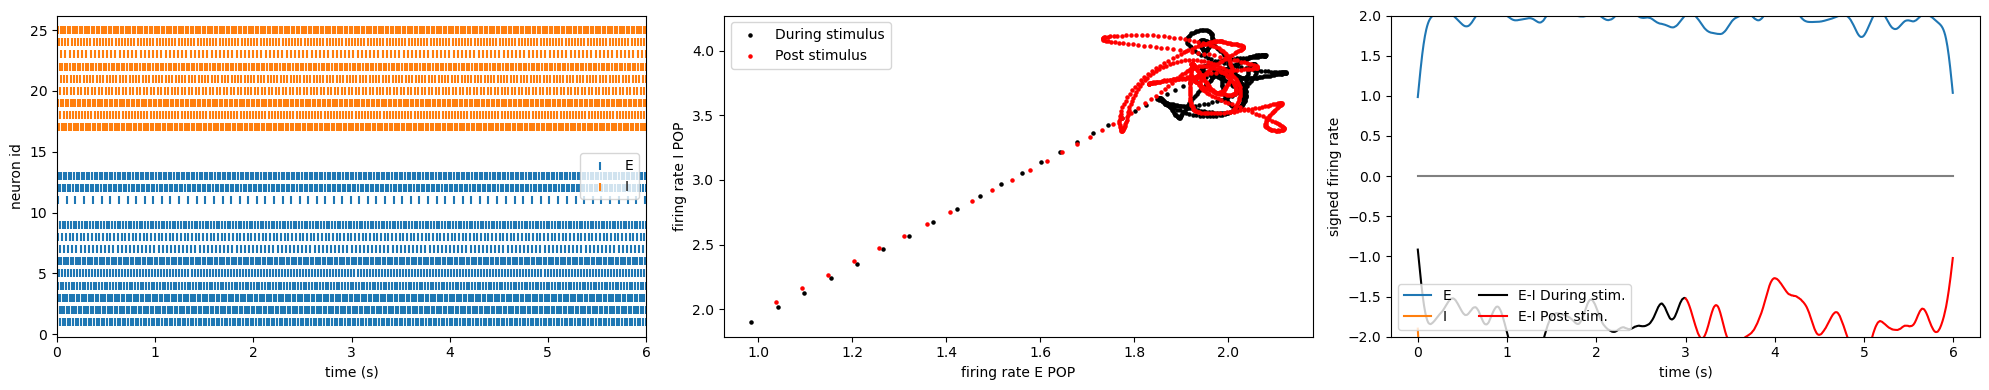

In [24]:
# E mean firing rate
for rate in [50]:
    fs = 200
    binPOP = np.zeros((2,int(D*fs)))
    for i in range(len(events)):
        if(spike_t[i]<D):
            binPOP[spike_id[i]//NE,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))

    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label='E')
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label='I')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)


    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel('firing rate I POP')
    ax2.set_xlabel('firing rate E POP')
    ax2.legend()

    ax3.plot(np.arange(int(D*fs))/fs,binPOP[0]/NE,label='E')
    ax3.plot(np.arange(int(D*fs))/fs,-binPOP[1]/NI,label='I')
    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE-binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax3.plot([0,D],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='lower left', ncol=2)
    ax3.set_ylim(-2,2)

    plt.tight_layout()
    #plt.savefig('EI.png')
    plt.show()